In [3]:
import pandas as pd
import shap
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/processed/cleaned_telco_churn.csv')

In [8]:
df['Total Charges'] = pd.to_numeric(
    df['Total Charges'],
    errors='coerce'
)

df = df.dropna()

df = pd.get_dummies(df, drop_first=True)

In [9]:
X = df.drop('Churn Value', axis=1)

y = df['Churn Value']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
model = joblib.load('../models/churn_model.pkl')

In [14]:
explainer = shap.Explainer(model, X_train)

In [15]:
X_train = X_train.astype(float)

X_test = X_test.astype(float)

In [16]:
explainer = shap.Explainer(model, X_train)

shap_values = explainer(X_test)

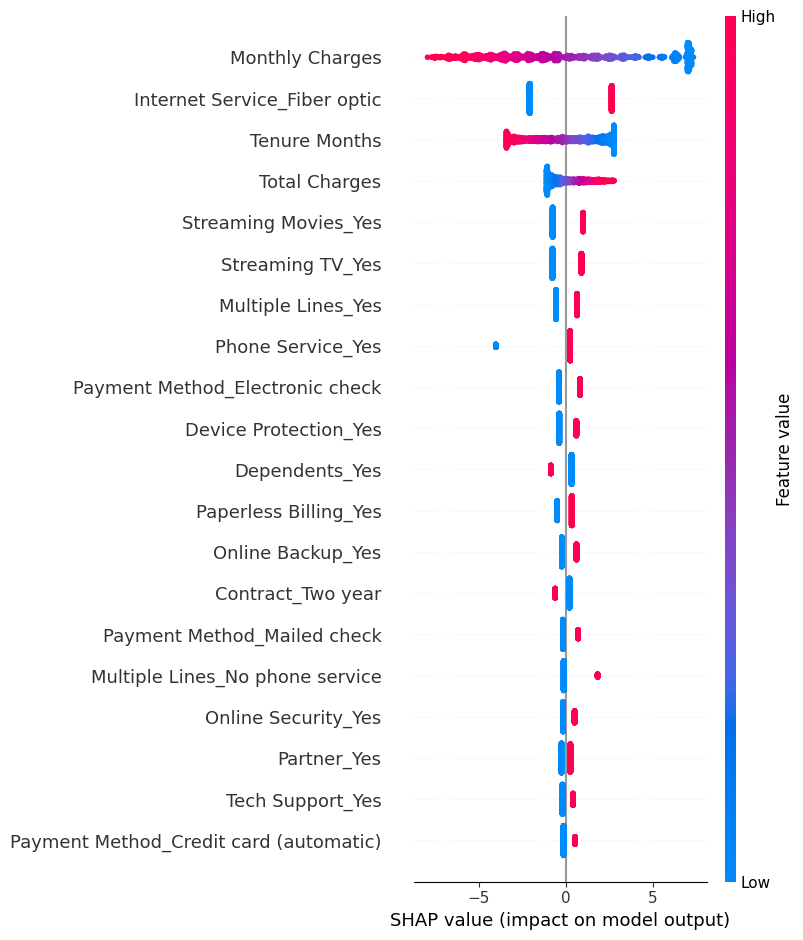

In [17]:
shap.summary_plot(shap_values, X_test)